In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/metadata.csv
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2580.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2617.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2794.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2696.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2585.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2637.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2537.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torchvision import models
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [3]:
# Define Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# Define Image Transformations
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [5]:
transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [6]:
# Load EyePACS Dataset
data_dir = "/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg"
train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=transform_train)
val_dataset = datasets.ImageFolder(root=f"{data_dir}/validation", transform=transform_val_test)
test_dataset = datasets.ImageFolder(root=f"{data_dir}/test", transform=transform_val_test)

In [7]:
# Create Data Loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [8]:
# Load Pretrained DenseNet121
model = models.densenet121(pretrained=True)
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 2)  # 2 classes: glaucoma and non-glaucoma
model = model.to(device)
print(model)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [9]:
# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [11]:
import torch
import torch.nn as nn
from torchvision import models

# Set the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example input tensor (batch size = 1, 3 color channels, 224x224 image size)
example_input = torch.randn(1, 3, 224, 224).to(device)  # Move the input tensor to the same device as the model

# Pass the input through the feature extractor (features attribute)
features = model.features(example_input)

# Check the shape of the extracted features
print(f"Extracted features shape: {features.shape}")

# Number of features extracted (flattened size)
num_features = features.shape[1]
print(f"Number of features extracted: {num_features}")


Extracted features shape: torch.Size([1, 1024, 7, 7])
Number of features extracted: 1024


In [12]:

# Training Function
def train(model, train_loader, val_loader, epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix(loss=running_loss / total, acc=100.0 * correct / total)

        train_loss = running_loss / len(train_loader)
        train_acc = 100.0 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        val_acc, val_loss = validate(model, val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model, "best_densenet121_model.pth")

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

    # Save final model
    torch.save(model, "final_densenet121_model.pth")
    print("Final model saved as final_densenet121_model.pth")

    return train_losses, val_losses, train_accuracies, val_accuracies

# Validation Function
def validate(model, val_loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100.0 * correct / total
    return val_acc, val_loss

# Train the model
train_losses, val_losses, train_accuracies, val_accuracies = train(model, train_loader, val_loader, epochs=10)

Epoch 1/10: 100%|██████████| 250/250 [00:49<00:00,  5.01it/s, acc=75.5, loss=0.0155]


Epoch 1: Train Loss=0.4953, Train Acc=75.45%, Val Loss=0.3265, Val Acc=86.49%


Epoch 2/10: 100%|██████████| 250/250 [00:49<00:00,  5.07it/s, acc=85.7, loss=0.0106]


Epoch 2: Train Loss=0.3391, Train Acc=85.72%, Val Loss=0.2494, Val Acc=90.13%


Epoch 3/10: 100%|██████████| 250/250 [00:49<00:00,  5.03it/s, acc=88.3, loss=0.00889]


...

Epoch 8: Train Loss=0.1734, Train Acc=93.39%, Val Loss=0.1979, Val Acc=92.47%


Epoch 9/10: 100%|██████████| 250/250 [00:49<00:00,  5.06it/s, acc=93.9, loss=0.00498]


Epoch 9: Train Loss=0.1593, Train Acc=93.92%, Val Loss=0.1843, Val Acc=92.47%


Epoch 10/10: 100%|██████████| 250/250 [00:49<00:00,  5.07it/s, acc=94.3, loss=0.00476]


Epoch 10: Train Loss=0.1523, Train Acc=94.31%, Val Loss=0.1794, Val Acc=93.25%
Final model saved as final_densenet121_model.pth


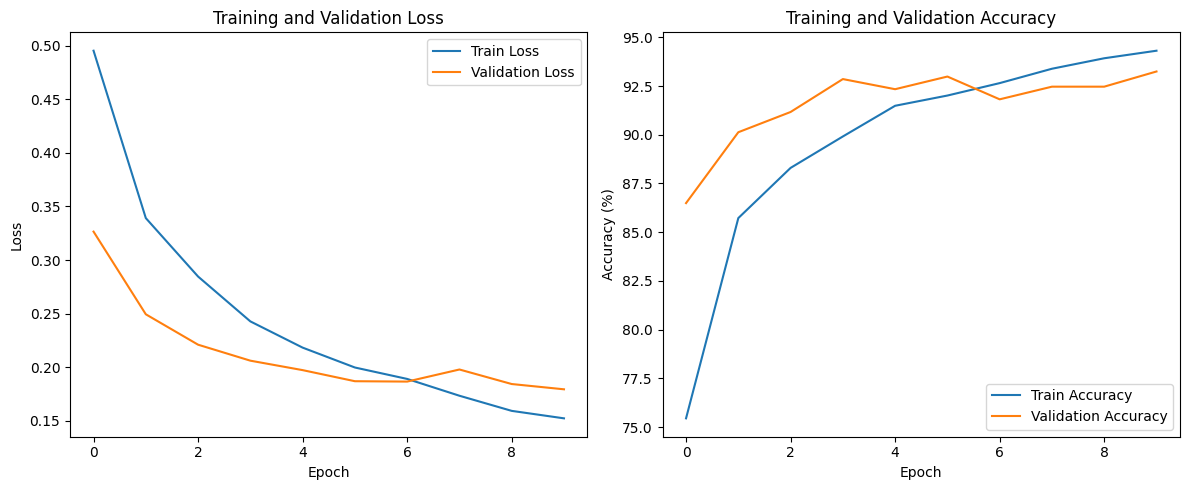

In [13]:
import matplotlib.pyplot as plt
# Plot Training and Validation Metrics
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
# Test Function
def test(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    test_acc = 100.0 * correct / total
    print(f"Test Accuracy: {test_acc:.2f}%")
    return all_labels, all_preds

# Test the model
model.load_state_dict(torch.load("best_densenet121_model.pth"))
labels, preds = test(model, test_loader)

<ipython-input-14-d08592478da8>:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_densenet121_model.pth"))
Testing: 100%|██████████| 2

Test Accuracy: 91.82%


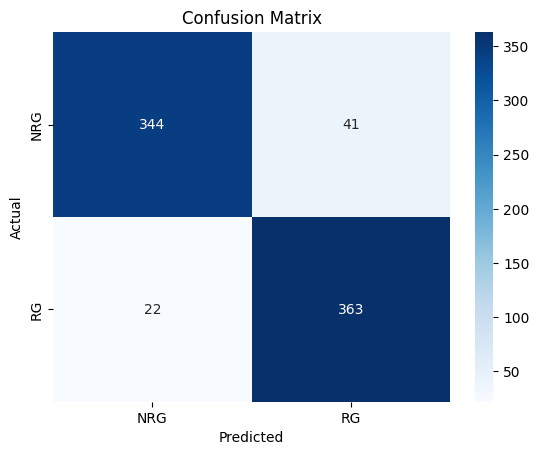

In [15]:
# Confusion Matrix and Classification Report
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [16]:
print(classification_report(labels, preds, target_names=test_dataset.classes))

              precision    recall  f1-score   support

         NRG       0.94      0.89      0.92       385
          RG       0.90      0.94      0.92       385

    accuracy                           0.92       770
   macro avg       0.92      0.92      0.92       770
weighted avg       0.92      0.92      0.92       770

